ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [29]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [30]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("student_admission_record_dirty.csv")
df.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
5,Murtaza,23.0,Female,NaN,NaN,Islamabad,Accepted
6,Asad,18.0,Male,NaN,97.31,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
8,Rohail,17.0,Male,64.0,NaN,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [31]:
df.dtypes

Name                       object
Age                       float64
Gender                     object
Admission Test Score      float64
High School Percentage    float64
City                       object
Admission Status           object
dtype: object

The dataset contains both numerical and categorical columns. Numerical columns such as Age, Admission Test Score, and High School Percentage are correctly stored as float64. Categorical columns such as Name, Gender, City, and Admission Status are stored as object type.

No incorrect data types were detected in the dataset.

In [32]:
df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


6

## The dataset contains missing values in both numerical and categorical columns, as well as duplicate records. These issues can affect the accuracy and reliability of analysis if not handled properly.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values can reduce data quality and affect the accuracy of preprocessing and analysis. Therefore, missing values must be identified and handled properly before applying machine learning techniques.


In [33]:
df.isna().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

The output shows that several columns contain missing values in both numerical and categorical data. These missing values need to be handled before continuing with preprocessing tasks.

### 3.2 Missing Value Handling Strategy

The dataset already contains real missing values in several columns. Therefore, no artificial missing values were introduced.


In [34]:
print("Original shape:", df.shape)


Original shape: (157, 7)


In [35]:
df.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
5,Murtaza,23.0,Female,NaN,NaN,Islamabad,Accepted
6,Asad,18.0,Male,NaN,97.31,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
8,Rohail,17.0,Male,64.0,NaN,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [36]:
df_DROP = df.dropna()

In [37]:
df_DROP.isna().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

In [57]:
df_DROP

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
10,Shafiq,17.0,Male,78.0,-10.00,Quetta,Rejected
...,...,...,...,...,...,...,...
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted


Rows containing missing values were removed from the dataset. This strategy is effective when the number of missing records is small and does not significantly reduce the dataset size.

### Strategy 2: Mean Imputation

![Mean.png](img\Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [38]:
df.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
5,Murtaza,23.0,Female,NaN,NaN,Islamabad,Accepted
6,Asad,18.0,Male,NaN,97.31,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
8,Rohail,17.0,Male,64.0,NaN,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected


In [39]:
# Strategy 2: Mean Imputation

df_imputed_mean = df.copy()

# Calculate mean values for numerical columns
mean_age = df_imputed_mean['Age'].mean()
mean_score = df_imputed_mean['Admission Test Score'].mean()
mean_percentage = df_imputed_mean['High School Percentage'].mean()

# Fill missing numerical values with mean
df_imputed_mean['Age'] = df_imputed_mean['Age'].fillna(mean_age)
df_imputed_mean['Admission Test Score'] = df_imputed_mean['Admission Test Score'].fillna(mean_score)
df_imputed_mean['High School Percentage'] = df_imputed_mean['High School Percentage'].fillna(mean_percentage)

# Fill missing categorical values with Unknown
df_imputed_mean['Name'] = df_imputed_mean['Name'].fillna('Unknown')
df_imputed_mean['Gender'] = df_imputed_mean['Gender'].fillna('Unknown')
df_imputed_mean['City'] = df_imputed_mean['City'].fillna('Unknown')
df_imputed_mean['Admission Status'] = df_imputed_mean['Admission Status'].fillna('Unknown')

# Check missing values after imputation
df_imputed_mean.isnull().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

In [40]:
df_imputed_mean.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.000000,68.900000,Quetta,Rejected
1,Waqar,21.0,Female,99.000000,60.730000,Karachi,Unknown
2,Bushra,17.0,Male,89.000000,75.684726,Islamabad,Accepted
3,Aliya,17.0,Male,55.000000,85.290000,Karachi,Rejected
4,Bilal,20.0,Male,65.000000,61.130000,Lahore,Unknown
5,Murtaza,23.0,Female,77.657534,75.684726,Islamabad,Accepted
6,Asad,18.0,Male,77.657534,97.310000,Multan,Accepted
7,Rabia,20.0,Female,82.000000,55.670000,Lahore,Accepted
8,Rohail,17.0,Male,64.000000,75.684726,Karachi,Accepted
9,Kamran,18.0,Male,53.000000,98.980000,Multan,Rejected


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [41]:
# Strategy 3: Median Imputation

df_imputed_median = df.copy()

# Calculate median values for numerical columns
median_age = df_imputed_median['Age'].median()
median_score = df_imputed_median['Admission Test Score'].median()
median_percentage = df_imputed_median['High School Percentage'].median()

# Fill missing numerical values with median
df_imputed_median['Age'] = df_imputed_median['Age'].fillna(median_age)

df_imputed_median['Admission Test Score'] = (
    df_imputed_median['Admission Test Score']
    .fillna(median_score)
)

df_imputed_median['High School Percentage'] = (
    df_imputed_median['High School Percentage']
    .fillna(median_percentage)
)

# Fill missing categorical values with "Unknown"
df_imputed_median['Name'] = (
    df_imputed_median['Name']
    .fillna('Unknown')
)

df_imputed_median['Gender'] = (
    df_imputed_median['Gender']
    .fillna('Unknown')
)

df_imputed_median['City'] = (
    df_imputed_median['City']
    .fillna('Unknown')
)

df_imputed_median['Admission Status'] = (
    df_imputed_median['Admission Status']
    .fillna('Unknown')
)

# Check missing values after imputation
df_imputed_median.isnull().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

In [42]:
df_imputed_median.head(10)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.900,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.730,Karachi,Unknown
2,Bushra,17.0,Male,89.0,77.545,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.290,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.130,Lahore,Unknown
5,Murtaza,23.0,Female,79.0,77.545,Islamabad,Accepted
6,Asad,18.0,Male,79.0,97.310,Multan,Accepted
7,Rabia,20.0,Female,82.0,55.670,Lahore,Accepted
8,Rohail,17.0,Male,64.0,77.545,Karachi,Accepted
9,Kamran,18.0,Male,53.0,98.980,Multan,Rejected


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

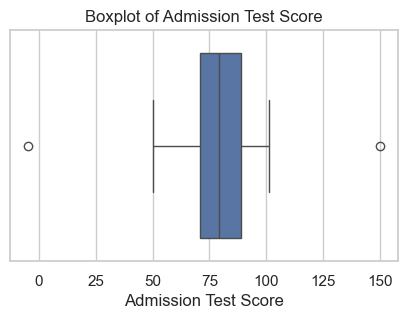

In [43]:
plt.figure(figsize=(5,3))

sns.boxplot(x=df_imputed_median['Admission Test Score'])

plt.title("Boxplot of Admission Test Score")

plt.show()

Points outside the whiskers represent potential outliers in the Admission Test Score column. These extreme values may affect preprocessing and analysis results.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [47]:
Q1 = df_imputed_median['Admission Test Score'].quantile(0.25)

Q3 = df_imputed_median['Admission Test Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_imputed_median[
    (df_imputed_median['Admission Test Score'] < lower) |
    (df_imputed_median['Admission Test Score'] > upper)
]

outliers.head(15)

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
31,Rehan,19.0,Female,-5.0,61.91,Quetta,Rejected
91,Umar,22.0,Male,150.0,77.69,Unknown,Rejected


The IQR method identifies outliers based on statistical boundaries. Values below the lower bound or above the upper bound are considered potential outliers.


### Remove Outliers
We remove values outside the acceptable range.

In [48]:
df_no_outliers = df_imputed_median[
    (df_imputed_median['Admission Test Score'] >= lower) &
    (df_imputed_median['Admission Test Score'] <= upper)
]

print("Original shape:", df_imputed_median.shape)

print("After removing outliers:", df_no_outliers.shape)

Original shape: (157, 7)
After removing outliers: (155, 7)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](img/percentile.png)

In [49]:
lower_cap = df_imputed_median['Admission Test Score'].quantile(0.05)

upper_cap = df_imputed_median['Admission Test Score'].quantile(0.95)

df_capped = df_imputed_median.copy()

df_capped['Admission Test Score'] = (
    df_capped['Admission Test Score']
    .clip(lower_cap, upper_cap)
)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [50]:
df_no_outliers[
    ['Age', 'Admission Test Score', 'High School Percentage']
].head()

,Age,Admission Test Score,High School Percentage
0,24.0,50.0,68.900
1,21.0,99.0,60.730
2,17.0,89.0,77.545
3,17.0,55.0,85.290
4,20.0,65.0,61.130


In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_no_outliers[
    ['Age', 'Admission Test Score', 'High School Percentage']
].copy()

df_scaled[
    ['Age', 'Admission Test Score', 'High School Percentage']
] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Age,Admission Test Score,High School Percentage
0,1.00,0.000000,0.654772
1,0.88,0.960784,0.586971
2,0.72,0.764706,0.726515
3,0.72,0.098039,0.790788
4,0.84,0.294118,0.590290


After applying Min-Max normalization, all numerical values are scaled between 0 and 1. This helps make features comparable even when their original ranges are different.


### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df_no_outliers[
    ['Age', 'Admission Test Score', 'High School Percentage']
].copy()

df_standardized[
    ['Age', 'Admission Test Score', 'High School Percentage']
] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Age,Admission Test Score,High School Percentage
0,0.978765,-2.028763,-0.417045
1,0.297439,1.544626,-0.904306
2,-0.610996,0.815363,0.098545
3,-0.610996,-1.664131,0.560459
4,0.070330,-0.934868,-0.880450


After applying Z-score normalization, the numerical features are standardized so that each feature has a mean close to 0 and a standard deviation close to 1. This transformation is useful before applying PCA and other machine learning techniques.


## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

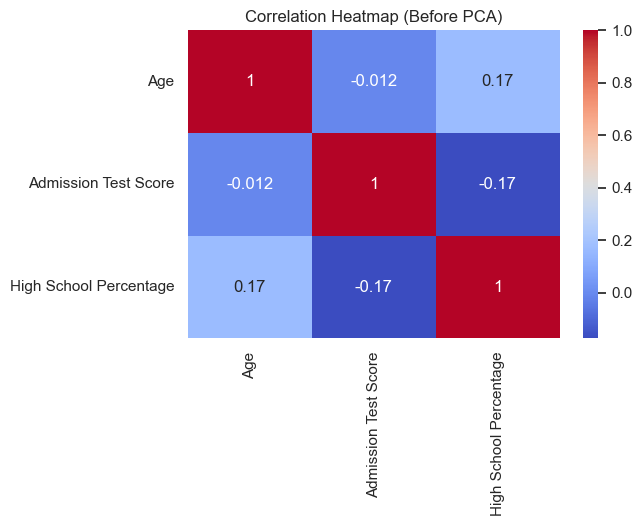

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df_standardized[
        ['Age', 'Admission Test Score', 'High School Percentage']
    ].corr(),
    
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (Before PCA)")

plt.show()

The heatmap shows the correlation between the numerical features in the dataset. Correlation values closer to 1 or -1 indicate stronger relationships, while values closer to 0 indicate weaker relationships.

The numerical features show weak correlations with each other, which means there are limited linear relationships between the variables. PCA can still be applied to reduce dimensionality and simplify the dataset while preserving important information.


## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [54]:
from sklearn.decomposition import PCA

X = df_standardized[
    ['Age', 'Admission Test Score', 'High School Percentage']
]

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

Explained Variance Ratio: [0.41562769 0.32928717]


The explained variance ratio shows how much information is preserved by each principal component.

In this dataset, the first principal component explains approximately 41.6% of the variance, while the second component explains approximately 32.9%.

Together, the two components preserve most of the important information from the original numerical features.


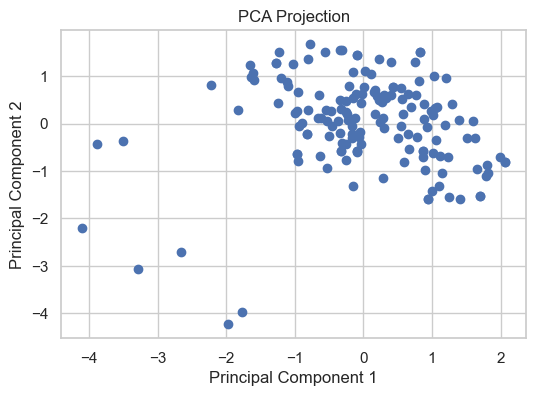

In [55]:
plt.figure(figsize=(6,4))

plt.scatter(
    principal_components[:,0],
    principal_components[:,1]
)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Each point in this scatter plot represents one student record projected onto the two principal components.

The PCA projection helps visualize the dataset in a lower-dimensional space while preserving most of the important information from the original numerical features.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2